## Step 0 — Setup

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
print("pandas:", pd.__version__)

pandas: 2.3.3


## Step 1 — Upload `ico_coffee_long_with_population.csv`

In [3]:
try:
    from google.colab import files
    print("Running in Colab — select ico_coffee_long_with_population.csv...")
    uploaded = files.upload()
except ImportError:
    print("Not running in Colab — make sure the file is already in the working directory.")

DATA_PATH = Path("ico_coffee_long_with_population.csv")
assert DATA_PATH.exists(), f"{DATA_PATH} not found — upload it in the cell above."


Not running in Colab — make sure the file is already in the working directory.


## Step 2 — Load and pick the countries to compare

In [4]:
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} rows, {df['Country'].nunique()} countries")

COUNTRIES = ["Thailand", "Philippines", "Peru", "Viet Nam"]  # <- edit this list

subset = df[
    (df.Country.isin(COUNTRIES))
    & (df.Metric.isin(["production_kg", "domestic_consumption_kg"]))
].copy()
subset["value_million_kg"] = subset["value"] / 1e6
subset["Metric_label"] = subset["Metric"].map({
    "production_kg": "Production",
    "domestic_consumption_kg": "Domestic Consumption",
})

print(f"Rows for the {len(COUNTRIES)} selected countries: {len(subset):,}")
subset.head()

Loaded 8,640 rows, 91 countries
Rows for the 4 selected countries: 240


,Country,Coffee type,Metric,Year,value,is_imputed,population,value_million_kg,Metric_label
1170,Peru,Arabica,domestic_consumption_kg,1990.0,11400000.0,False,22014771.0,11.4,Domestic Consumption
1171,Peru,Arabica,domestic_consumption_kg,1991.0,11400000.0,False,22483775.0,11.4,Domestic Consumption
1172,Peru,Arabica,domestic_consumption_kg,1992.0,12000000.0,False,22946340.0,12.0,Domestic Consumption
1173,Peru,Arabica,domestic_consumption_kg,1993.0,12000000.0,False,23413783.0,12.0,Domestic Consumption
1174,Peru,Arabica,domestic_consumption_kg,1994.0,12000000.0,False,23881493.0,12.0,Domestic Consumption


## Step 3 — Plot: one panel per country

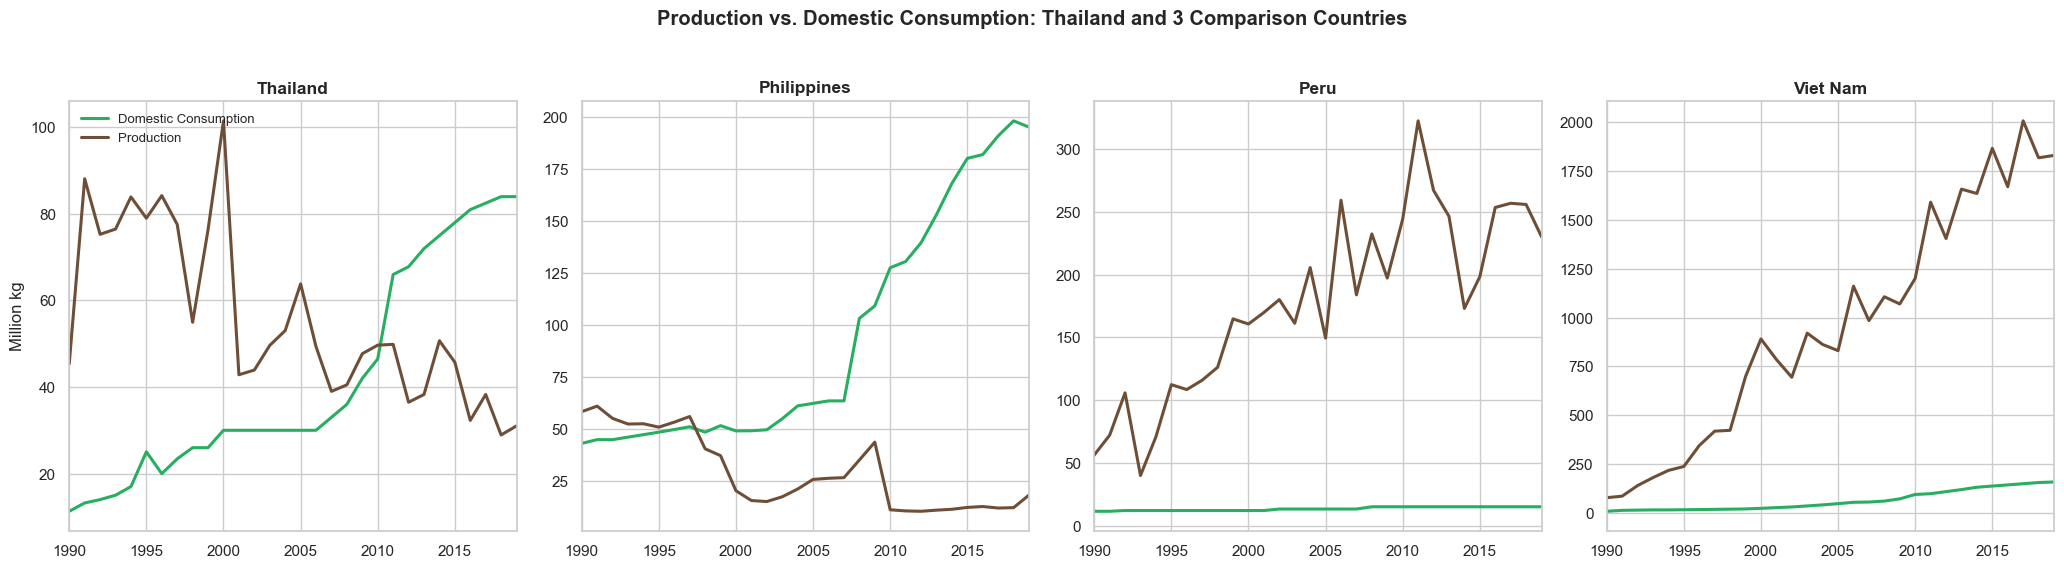

In [5]:
n = len(COUNTRIES)
fig, axes = plt.subplots(1, n, figsize=(5.2 * n, 5.5), sharey=False)
PALETTE = {"Production": "#6f4e37", "Domestic Consumption": "#27ae60"}

for ax, country in zip(axes, COUNTRIES):
    country_df = subset[subset.Country == country].sort_values("Year")
    sns.lineplot(data=country_df, x="Year", y="value_million_kg", hue="Metric_label",
                 ax=ax, linewidth=2.2, palette=PALETTE, legend=(country == COUNTRIES[0]))
    ax.set_title(country, fontsize=12.5, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Million kg" if country == COUNTRIES[0] else "")
    ax.set_xlim(1990, 2019)

axes[0].legend(loc="upper left", frameon=False, fontsize=9.5, title="")
fig.suptitle("Production vs. Domestic Consumption: Thailand and 3 Comparison Countries",
             fontsize=14.5, fontweight="bold", y=1.03)

plt.tight_layout()
#plt.savefig("compare_production_consumption.png", dpi=160, bbox_inches="tight", facecolor="white")
plt.show()

## Step 4 — Download the chart (Colab only)

In [ ]:
try:
    from google.colab import files as _colab_files
    _colab_files.download("compare_production_consumption.png")
except ImportError:
    print(f"Not in Colab — find it locally at: {Path('compare_production_consumption.png').resolve()}")

## What to look for

- **Thailand & Philippines**: production trending down, consumption trending up — lines cross partway through
- **Peru**: the opposite — production climbing, consumption barely moving
- **Viet Nam**: both lines climb, but production so steeply it dwarfs consumption on the same scale

This is a visual/qualitative comparison — no correlation or similarity score is computed here. Swap `COUNTRIES` in Step 2 to compare any other set of producing countries the same way.